In [1]:
from datascience import *
from datascience import percentile
import numpy as np
import math
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use("fivethirtyeight")

/opt/conda/lib/python3.12/site-packages/datascience/maps.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# House Data Analysis

In [2]:
# import data
real_estate = Table.read_table('riga_re.csv')
real_estate.show(5)

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166


### A. Dataset Description

The dataset contains 4689 real estate objects in Riga.

Columns description:

op_type - offer type ('For rent', 'For sale', 'Buying', 'Renting', 'Change', 'Other').

district - district, where real estate object located.

street - address of real estate object.

rooms - number of rooms.

area - living area of real estate object.

floor - floor of rel estate object.

total_floors - total amount of floors in building.

house_seria - house design ('LT proj.', '602.', 'P. kara', 'Jaun.', 'Specpr.', 'Hrušč.', '119.', 'M. ģim.', 'Renov.', '103.', nan, 'Priv. m.', '467.', 'Staļina', '104.', 'Čehu pr

house_type - type of building ('Brick-Panel', 'Panel', 'Wood', 'Masonry', 'Brick', 'Panel-Brick').

condition - stuffing premises ('All amenities', 'Partial amenities', 'Without amenities').

price - price in EUR.

lat / lon - latitude and longitude of real estate object.

### B. Why did I choose this dataset?

I looked at data.gov but did not find a dataset that meets the requirements. Then I tried the Kaggle website and found this dataset. It meets the requirements for the number of rows, variables, number of numerical variables, and the number of string variables. That's why I chose this dataset.

### C. Source of Dataset
https://www.kaggle.com/datasets/trolukovich/riga-real-estate-dataset

### D. Use programming code to:

list the dimensions (rows and columns) of the dataset.

list the column names and their data types.

list the first 10 observations in the dataset.


In [3]:
# lists the number of rows in the dataset
real_estate.num_rows

4689

In [4]:
# lists the number of columns in the dataset
real_estate.num_columns

13

In [5]:
# lists the column names and their data types
real_estate.labels

('op_type',
 'district',
 'street',
 'rooms',
 'area',
 'floor',
 'total_floors',
 'house_seria',
 'house_type',
 'condition',
 'price',
 'lat',
 'lon')

In [6]:
# lists the data types of the columns
for current_column in real_estate.labels:
    print(str(current_column) + ' is a ' + str(type(real_estate.column(current_column).item(0))))

op_type is a <class 'str'>
district is a <class 'str'>
street is a <class 'str'>
rooms is a <class 'str'>
area is a <class 'float'>
floor is a <class 'float'>
total_floors is a <class 'float'>
house_seria is a <class 'str'>
house_type is a <class 'str'>
condition is a <class 'str'>
price is a <class 'float'>
lat is a <class 'float'>
lon is a <class 'float'>


In [7]:
# lists the first 10 observations in the dataset
real_estate.show(10)

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166
For rent,centrs,Ģertrūdes 16,2,40,3,6,P. kara,Masonry,All amenities,440,56.9567,24.1238
For sale,Ķengarags,Lokomotīves 20,2,37,5,5,Specpr.,Brick,All amenities,31000,56.9153,24.1894
For rent,Imanta,Kurzemes pr. 46,2,49,3,5,LT proj.,Panel,All amenities,240,nan,nan
For rent,centrs,Avotu 7,2,48,5,5,P. kara,Brick,All amenities,400,56.9509,24.1284
For rent,Jugla,Juglas 53,2,45,2,5,Hrušč.,Panel,All amenities,360,56.9762,24.2545


In [8]:
# makes a copy of the original dataframe
real_estate_copy = real_estate.copy()
real_estate_copy

op_type,district,street,rooms,area,floor,total_floors,house_seria,house_type,condition,price,lat,lon
For rent,Purvciems,Dzelzavas 93,1,27,3,5,LT proj.,Brick-Panel,All amenities,250,56.9555,24.2021
For rent,Ziepniekkalns,Ozolciema 32,2,50,7,9,602.,Panel,All amenities,300,56.8998,24.0984
For sale,centrs,Ieroču 6,2,33,1,2,P. kara,Wood,Partial amenities,13500,56.9751,24.1399
For sale,Ķengarags,Maskavas 305,2,50,5,5,LT proj.,Panel,All amenities,34000,56.8598,24.3083
For rent,Teika,Zemgala gatve 80,3,76,3,12,Jaun.,Masonry,All amenities,490,56.9777,24.166
For rent,centrs,Ģertrūdes 16,2,40,3,6,P. kara,Masonry,All amenities,440,56.9567,24.1238
For sale,Ķengarags,Lokomotīves 20,2,37,5,5,Specpr.,Brick,All amenities,31000,56.9153,24.1894
For rent,Imanta,Kurzemes pr. 46,2,49,3,5,LT proj.,Panel,All amenities,240,nan,nan
For rent,centrs,Avotu 7,2,48,5,5,P. kara,Brick,All amenities,400,56.9509,24.1284
For rent,Jugla,Juglas 53,2,45,2,5,Hrušč.,Panel,All amenities,360,56.9762,24.2545


## E. Do the following: 

For at least 5 variables, check the quality of the data and think about how you might need to prepare it for analysis. Are there missing values? Are there strange values? Is it helpful to standardize any of the variables? Describe and show your checks.


In [9]:
# Check if there are missing values in a row
for current_column in real_estate_copy.labels:
    has_missing = any(value is None or (isinstance(value, float) and np.isnan(value))
                  for value in real_estate_copy.column(current_column))

    print(f"Column '{current_column}' has missing values:", has_missing)

Column 'op_type' has missing values: False
Column 'district' has missing values: False
Column 'street' has missing values: False
Column 'rooms' has missing values: False
Column 'area' has missing values: True
Column 'floor' has missing values: True
Column 'total_floors' has missing values: True
Column 'house_seria' has missing values: False
Column 'house_type' has missing values: False
Column 'condition' has missing values: False
Column 'price' has missing values: True
Column 'lat' has missing values: True
Column 'lon' has missing values: True


There are missing values in the columns 'area', 'floor', 'total_floors', 'price', 'lat', and 'lon'. There are strange values in the 'street' and 'house_seria' columns. I don't need to standardize any of the variables

### F. EDA (Exploratory Data Analysis)

The primary goal of EDA is to explore the underlying structure, patterns, relationships, and anomalies within the data, allowing the analyst to make informed decisions and develop appropriate models or strategies for further analysis. This usually involves some combination of the following:

Cleaning (e.g., removing duplicates)

Transformations (e.g., aggregation, grouping)

Descriptive/univariate analysis (e.g., summary statistics)

Correlational/bivariate analysis (e.g., correlation values, simple hypothesis testing)

Visualizations (e.g., histograms, scatter plots)


In [10]:
# mean of values in the 'price' column (excluding missing values)
np.nanmean(real_estate_copy.column('price'))

58728.706802559849

In [11]:
# mean of values in the 'area' column (excluding missing values)
np.nanmean(real_estate_copy.column('area'))

61.204557225433518

In [12]:
# variance of values in the 'price' column
np.nanvar(real_estate_copy.column('price'))

5813065831.0387096

In [13]:
# variance of values in the 'area' column
np.nanvar(real_estate_copy.column('area'))

1302.1859614975922

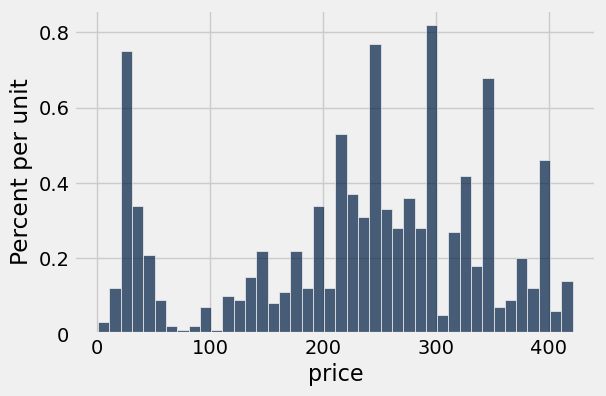

In [14]:
# gets maximum value in the 'price' column
max_price = np.nanmax(real_estate_copy.column('area'))

#gets minimum value in the 'price' column
min_price = np.nanmin(real_estate_copy.column('area'))

real_estate_copy.hist('price', bins = np.arange(min_price, max_price, 10))

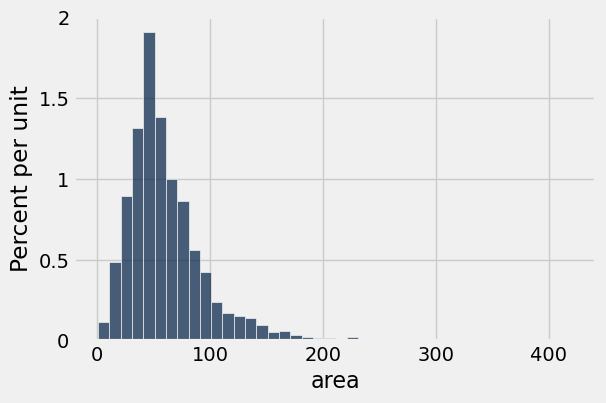

In [15]:
# gets maximum value in the 'area' column
max_area = np.nanmax(real_estate_copy.column('area'))

#gets minimum value in the 'area' column
min_area = np.nanmin(real_estate_copy.column('area'))

real_estate_copy.hist('area', bins = np.arange(min_area, max_area, 10))

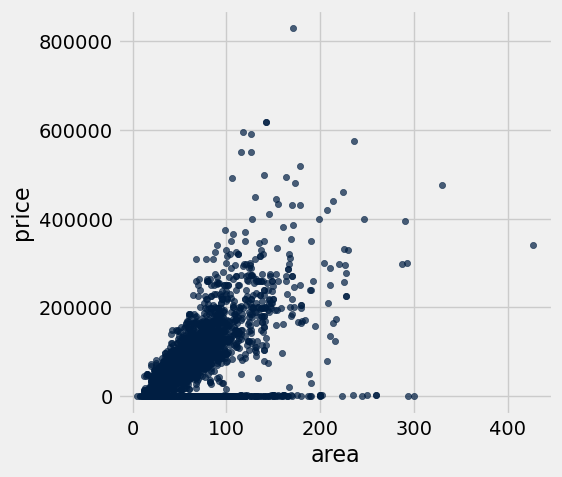

In [16]:
real_estate_copy.scatter('area', 'price')

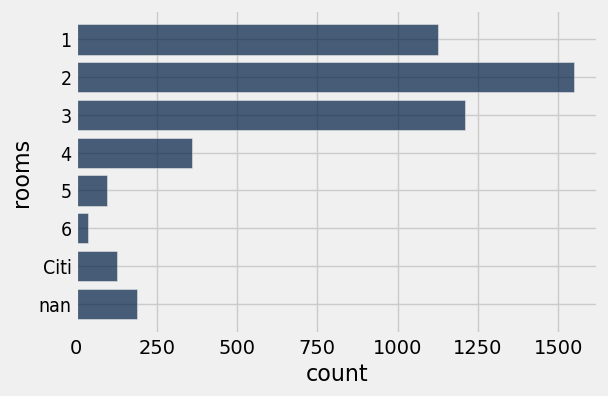

In [17]:
# makes a bar chart for the number of rooms
real_estate_copy.group('rooms').barh('rooms')

### G. Observations

From the scatterplot of area vs price, as the area goes up, we can see that the price goes up too.

From the horizontal bar chart of the number of rooms, most houses have 1-3 rooms.

In [18]:
# Cleans data to only contain rows without missing data
cleaned = real_estate.where(~np.isnan(real_estate.column("area")))

# selects only the op_type and area columns
pared = cleaned.select("op_type", "area")

In [19]:
pared

op_type,area
For rent,27
For rent,50
For sale,33
For sale,50
For rent,76
For rent,40
For sale,37
For rent,49
For rent,48
For rent,45


In [20]:
# Computes the test statistic
# Test statistic: average area for sale - average area for rent
avg_for_sale_area = np.mean(cleaned.where("op_type", are.equal_to("For sale")).column("area"))
avg_for_rent_area = np.mean(cleaned.where("op_type", are.equal_to("For rent")).column("area"))
test_stat = avg_for_sale_area - avg_for_rent_area
test_stat

10.404092696354276

In [21]:
def simulated_stat():
    sample_size = 1000
    num_repetitions = 1000
    simulated_stats = []

    for i in np.arange(num_repetitions):
        # Sample 500 rows from the pared table
        sample = pared.sample(with_replacement=False)

        # Shuffles op_type Labels within the sample
        shuffled_labels = sample.select("op_type").sample(with_replacement=False).column("op_type")

        # Adds shuffled labels to the same sample
        shuffled = sample.with_column("Shuffled Label", shuffled_labels)

        # Groups by shuffled labels and computes means
        grouped_means = shuffled.select("Shuffled Label", "area").group("Shuffled Label", np.mean)
        
        for_sale_area = grouped_means.where("Shuffled Label", are.equal_to("For sale")).column("area mean").item(0)
        for_rent_area = grouped_means.where("Shuffled Label", are.equal_to("For rent")).column("area mean").item(0)

        one_simulated_test_stat = for_sale_area - for_rent_area
        simulated_stats.append(one_simulated_test_stat)
        
    simulated_stats = np.array(simulated_stats)
    return simulated_stats

In [22]:
# creates an array of simulated statistics from the simulated_stat function
simulated_stats_array = simulated_stat()

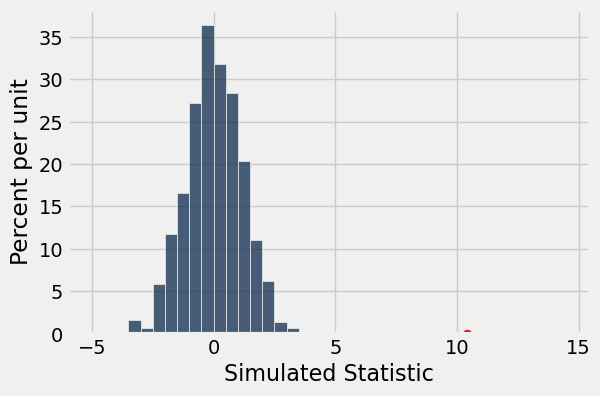

In [23]:
# Makes a histogram of the simulated statistics
simulated_tbl = Table().with_column("Simulated Statistic", simulated_stats_array)
simulated_hist = simulated_tbl.hist("Simulated Statistic", bins = np.arange(-5, 15, 0.5))
plots.scatter(test_stat, 0, color="red", s=40)

In [24]:
# calculates p-value
p_value = np.count_nonzero(simulated_stats_array >= test_stat) / len(simulated_stats_array)
print("p-value:", p_value)

p-value: 0.0


In [25]:
# creates a table containing only rows for houses on sale
for_sale = pared.where("op_type", are.equal_to("For sale"))

# function to bootstrap the mean
def bootstrap_mean_area(sample_size, num_repetitions):
    means = []

    for i in np.arange(num_repetitions):
        resample = for_sale.sample(sample_size, with_replacement=True)
        resample_mean = np.mean(resample.column("area"))
        means.append(resample_mean)

    return np.array(means)

In [26]:
# runs the bootstrap
bootstrap_means = bootstrap_mean_area(500, 1000)

In [27]:
# constructs 95% confidence interval
left_means = np.percentile(bootstrap_means, 2.5)
right_means = np.percentile(bootstrap_means, 97.5)
confidence_interval_95 = make_array(left_means, right_means)
print("95% Confidence Interval for mean area of houses for sale:", confidence_interval_95)

95% Confidence Interval for mean area of houses for sale: [ 62.7003735  69.0187645]


In [28]:
# filters out None values in the array bootstrap_means
cleaned_bootstrap_means = []
for m in bootstrap_means:
    if m is not None:
        cleaned_bootstrap_means.append(m)
        
cleaned_bootstrap_means = np.array(cleaned_bootstrap_means)

In [29]:
print("Min:", np.min(cleaned_bootstrap_means))
print("Max:", np.max(cleaned_bootstrap_means))
print("Example values:", cleaned_bootstrap_means[:])

Min: 59.83478
Max: 71.00468
Example values: [ 65.28108  69.4912   65.53788  63.294    66.83826  64.55868  65.68582
  64.1796   64.81926  64.83086  66.20392  65.07718  64.44472  65.77338
  65.0032   64.49864  66.7662   69.17984  63.2427   67.46144  64.74568
  66.08976  65.24394  66.38484  70.1876   64.1313   62.99918  67.13628
  67.18034  65.44906  64.82346  66.57882  64.7048   62.85766  65.57274
  65.56294  65.6944   64.39144  67.8936   65.32976  66.53918  66.7394
  66.99108  64.87392  64.8808   63.52172  67.08922  65.62466  64.25492
  67.13956  65.43916  64.76512  65.3807   62.76906  65.16988  64.25362
  68.47984  64.4019   68.00004  66.14432  67.19638  67.6397   64.20176
  66.745    68.0308   64.36668  66.01414  67.70626  64.39108  65.40736
  65.89286  64.71896  65.54558  68.22002  66.8453   62.0144   66.18148
  63.26434  66.60872  66.56304  68.85074  66.39992  66.60112  67.7062
  65.10612  63.62138  64.79268  63.23156  65.60982  65.52494  63.7159
  67.19456  67.26684  66.04212  65.6

In [30]:
# sets up the minimum and maximum values for the bootstrap histogram
min_val = np.floor(np.min(cleaned_bootstrap_means))
max_val = np.ceil(np.max(cleaned_bootstrap_means))
bootstrap_bins = np.arange(min_val, max_val + 1, 0.5)

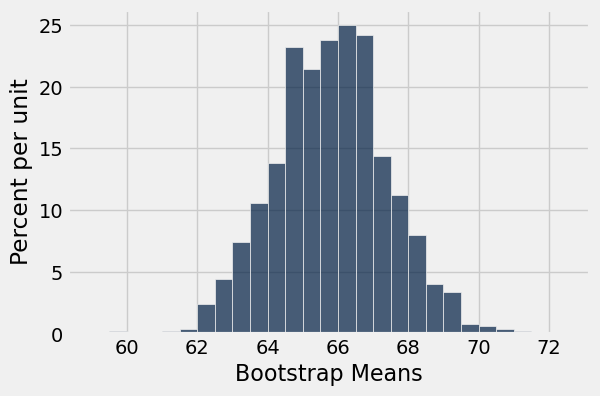

In [31]:
# Puts the cleaned_bootstrap_means array into a table
cleaned_bootstrap_means_tbl = Table().with_column("Bootstrap Means", cleaned_bootstrap_means) 

# Creates a histogram from the bootstrap table
bootstrap_hist = cleaned_bootstrap_means_tbl.hist("Bootstrap Means", bins = bootstrap_bins)
bootstrap_hist

In [32]:
# Gets area columns for houses that are for sale and for rent
for_sale_area = pared.where("op_type", are.equal_to("For sale")).column("area")
for_rent_area = pared.where("op_type", are.equal_to("For rent")).column("area")

# Finds the minimum length
min_length = min(len(for_sale_area), len(for_rent_area))

#Truncate both arrays to the same length
for_sale_area = for_sale_area[:min_length]
for_rent_area = for_rent_area[:min_length]

# Creates a table of the areas of for sale and for rent houses
real_estate_areas = Table().with_columns("For sale area", for_sale_area, "For rent area", for_rent_area)
real_estate_areas

For sale area,For rent area
33,27
50,50
37,76
46,40
58,49
50,48
60,45
46,44
36,50
36,40


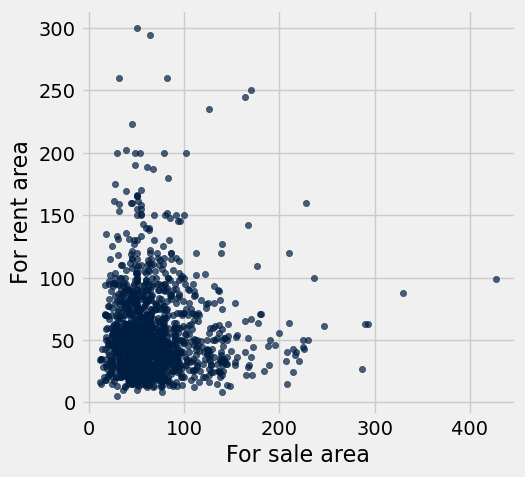

In [33]:
real_estate_areas.scatter("For sale area", "For rent area")

In [34]:
# converts an array into standard units
def standard_units(arr):
    return (arr - np.average(arr)) / np.std(arr)

# computes correlation: t is a table, and x and y are column names
def correlation(t, x, y):
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.mean(x_standard * y_standard)
    
# computes the slope of the regression line
def slope(t, x, y):
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

# computes the intercept of the regression line
def intercept(t, x, y):
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y) * x_mean

# creates the regression line for the scatterplot
def regression_line(t, x, y):
    m = slope(t, x, y)
    b = intercept(t, x, y)
    return m * t.column(x) + b

In [35]:
# computes the correlation between the areas of houses for rent and areas of houses for sale
real_estate_correlation = correlation(real_estate_areas, "For sale area", "For rent area")

# computes the slope of the data
real_estate_slope = slope(real_estate_areas, "For sale area", "For rent area")

# computes the intercept
real_estate_intercept = intercept(real_estate_areas, "For sale area", "For rent area")

# takes the slope and intercept to write the regression line in y=mx+b form
reg_line_printed = "y = {:.3f}x + {:.3f}".format(real_estate_slope, real_estate_intercept)

# creates predicted values for the 
reg_line_scattered = regression_line(real_estate_areas, "For sale area", "For rent area")

print("Correlation:", real_estate_correlation)
print("Regression Line:", reg_line_printed)

Correlation: 0.0018588700754
Regression Line: y = 0.002x + 55.259


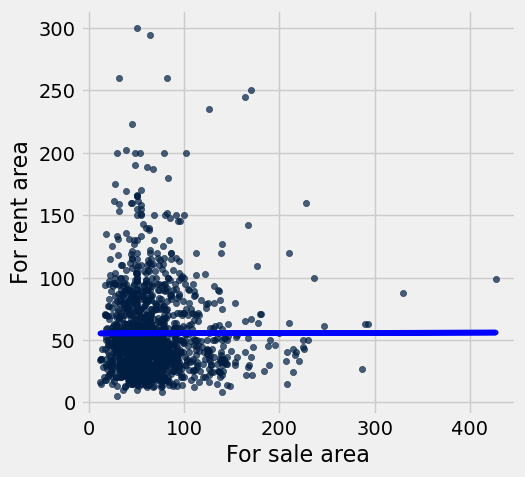

In [36]:
# appends the predicted values from the regression line function into the real estate table
real_estate_predicted = real_estate_areas.with_column("Predicted Values", reg_line_scattered)

# plots the original data as a scatter plot
real_estate_predicted.scatter("For sale area", "For rent area")

# plots the regression line on top
plots.plot(real_estate_predicted.column("For sale area"), real_estate_predicted.column("Predicted Values"), label="Regression Line", color="blue")